# Classification of Stress from Physiological data

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.figure as figure
import pandas as pd
from datetime import datetime
import joblib

from IPython.display import display

from imblearn.over_sampling import ADASYN, SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC, SVR, SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, RobustScaler
from sklearn.feature_selection import RFECV

from make_classification import avg_res, make_nclassif_random_splits, make_nclassif_kfold

BASE_PATH = "../.."
LABELS_SEPARATOR = ","
LABELS_FILENAME = f"{BASE_PATH}/stressID/labels.csv"
FEATURES_SEPARATOR = ","
FEATURES_DIRECTORY = f"{BASE_PATH}/Reprod-Features-StdSubject"
FEATURES_FILENAME = f"{FEATURES_DIRECTORY}/ecg_eda_features.csv"
RESULTS_SEPARATOR = ";"
RESULTS_DIRECTORY = f"{BASE_PATH}/stressID/Classification/Results_StdSubject_VidTasks"
BIN_LABELS = ["NoStress", "Stress"]
TER_LABELS = ["Relaxed", "Stress", "RealStress"]
QAD_LABELS = ["Relaxed", "Stress", "RealStress", "Amused"]
DEBUG = True
FLOAT_TYPE = np.float64

In [2]:
def make_results_filename(classification: str, splits: int, feature_selection: str | None, test_size: float, state_int: int) -> str:
    now = datetime.now()
    timestamp = now.strftime("%Y%m%d-%H%M%S")
    feature_selection = feature_selection if feature_selection is not None else "None"
    return f"{RESULTS_DIRECTORY}/{timestamp}_VidsTasks_{classification}_{splits}s&{test_size}_{feature_selection}f.{state_int}"

def show_label_stats(labels: list[str], y: pd.Series):
    display(pd.DataFrame(
        {
            "labels": labels,
            "counts": y.value_counts().to_list(),
            "percentage": (y.value_counts(normalize=True) * 100).to_list(),
        }
    ))

def output(results: pd.DataFrame, conf_matrices: dict[str, np.ndarray], meta: dict):
    classification = meta['classification']
    n_splits = meta['n_splits']
    feature_selector = meta['feature_selector']
    test_size = meta['test_size']
    state_int = meta['state_int']
    labels = meta['classes']
    averages = avg_res(results)
    if meta['save_results']:
        res_file = make_results_filename(classification, n_splits, feature_selector, test_size, state_int) + ".csv"
        avg_file = make_results_filename(classification, n_splits, feature_selector, test_size, state_int) + ".avg.csv"
        print(f"Saving results to {res_file}, {avg_file}")
        results.to_csv(res_file, sep=RESULTS_SEPARATOR, index=True)
        averages.to_csv(avg_file, sep=RESULTS_SEPARATOR, index=True)

    # Show results
    if meta['show_averages']:
        display(averages)
    if meta['show_confusion_matrices']:
        cm_file = make_results_filename(classification, n_splits, feature_selector, test_size, state_int) + ".CM.png"
        ncms = len(conf_matrices)
        pairs = [(name, cm) for name, cm in conf_matrices.items()]
        nrows = (ncms // 2) + (ncms % 2)
        fig, axes = plt.subplots(nrows, 2, figsize=(8, nrows*4))
        for (name, cm), ax in zip(pairs, axes.ravel()):
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
            ax.set_title(name)
        fig.suptitle("Confusion Matrices")
        plt.tight_layout()
        if meta["save_results"]:
            print(f"Saving confusion matrix to {cm_file}")
            plt.savefig(cm_file, dpi=300, format="png")
        plt.show()


def save_models(classifiers: dict[str, Pipeline], meta: dict):
    classification = meta["classification"]
    for name, cls in classifiers.items():
        now = datetime.now()
        timestamp = now.strftime("%Y%m%d-%H%M%S")
        filename = (
            f"{RESULTS_DIRECTORY}/{timestamp}_{classification}_{name}_{meta['feature_selector']}f.joblib"
        )
        joblib.dump(cls, filename)
        print(f"Model {name} saved to {filename}")

#### Import labels and prepare dataset

Manually engineered features

In [3]:
X = pd.read_csv(FEATURES_FILENAME, sep=FEATURES_SEPARATOR, header=0, index_col=0).dropna()
for col in X.columns:
    X[col] = X[col].astype(FLOAT_TYPE)
n_rows, n_cols = X.shape
print("======================================================")
print(f"StressID dataset contains {n_rows} samples with {n_cols} features")
# display(X)

labels = pd.read_csv(LABELS_FILENAME, sep=LABELS_SEPARATOR, header=0, index_col=0).dropna()
n_rows, n_cols = labels.shape
print("======================================================")
print(f"StressID labels contains {n_rows} labels with {n_cols} types of classifications")
# display(labels)

# Selecting rows that actually have entries both labels and samples
idx = list(X.merge(labels, left_index=True, right_index=True).index)
labels = labels.loc[idx]
X = X.loc[idx]
n_rows, n_cols = X.shape
print("======================================================")
print(f"StressID classification dataset contains {n_rows} samples with {n_cols} features")

video_tasks = ["Relax", "Video1", "Video2"]
video_tasks_mask = [task.split("_")[1] in video_tasks for task in X.index]


rel_X = X[video_tasks_mask]
rel_bin_y = labels['binary-stress'][video_tasks_mask]
rel_ter_y = labels['affect3-class'][video_tasks_mask]
rel_qad_y = labels['affect4-class'][video_tasks_mask]

subject_to_group: dict[str, int] = {}
subject_counter = 0
rel_subject_list: list[int] = []
for col_name, label in rel_bin_y.items():
    subject_id, task = col_name.split("_")
    if subject_id not in subject_to_group:
        subject_to_group[subject_id] = subject_counter
        subject_counter += 1
    rel_subject_list.append(subject_to_group[subject_id])

n_rows, n_cols = rel_X.shape
print("======================================================")
print(f"Video tasks dataset contains {n_rows} samples with {n_cols} features")
print(f"Video tasks subjects list is {len(rel_subject_list)} members long, having {len(set(rel_subject_list))} distinct subjects")

StressID dataset contains 773 samples with 70 features
StressID labels contains 700 labels with 3 types of classifications
StressID classification dataset contains 699 samples with 70 features
Video tasks dataset contains 188 samples with 70 features
Video tasks subjects list is 188 members long, having 64 distinct subjects


# Classical approaches

Several models are tested: Random Forests, K nearets neighbors, SVM, and Multi Layer Perceptron. All models are fitted 10 times on random splits, and the average scores over 10 repetitions are reported.

The dimensionality of the features matrix can be reduced using PCA or Feature selection. Feature selection is performed using L1 penalty or Recursive Feature Elimination (RFE). The optimal number of features is determined using RFECV.

### Parameter and models configuration

In [4]:
params = {
    "state_int": 21,
    "feature_selector": "RFE",  ###  None, 'PCA', 'L1', or 'RFE' (ordered by speed)
    "test_size": 0.2,  # Paper value: 0.2
    "n_splits": 10,  # Paper value: 10
    "data_augmentation": True,
    "show_averages": True,
    "show_confusion_matrices": True,
    "save_models": True,
    "save_results": True,
    "verbose": False,
}

validations = {
    'holdout': True,
    'kfold': True
}

list_classif = [
    RandomForestClassifier(bootstrap=True, max_depth=40, max_features="log2", min_samples_leaf=1, min_samples_split=2, n_estimators=450, random_state=params["state_int"]),
    KNeighborsClassifier(n_neighbors=2, p=1, weights="distance"),
    SVC(C=1000, gamma="auto", kernel="rbf", random_state=params["state_int"], probability=True),
    MLPClassifier(activation="tanh", alpha=0.008, hidden_layer_sizes=(100,), learning_rate_init=0.005, max_iter=10000, random_state=params["state_int"]),
]

### Binary classification

In [5]:
params['classification'] = 'binary'
params['classes'] = BIN_LABELS
show_label_stats(params['classes'], rel_bin_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy={0:165, 1:165})
    x_in, y_in = ada.fit_resample(rel_X, rel_bin_y)
    print("Resampled dataset")
    show_label_stats(params["classes"], y_in)
else:
    x_in = rel_X.copy()
    y_in = rel_bin_y.copy()

    # Visualise class distribution
    plt.figure(figsize=(12, 6))

    bin_stats = pd.DataFrame(
        {
            "Value": y_in.values,
            "Subject": [idx.split("_")[0] for idx in y_in.index],
            "Task": [idx.split("_")[1] for idx in y_in.index],
        },
        index=y_in.index,
    )
    for cls_id, cls_name in enumerate(params["classes"]):
        bin_stats[cls_name] = [value == cls_id for value in y_in]

    tasks = sorted(bin_stats['Task'].unique())
    x_positions = np.arange(len(tasks))
    width = 0.35

    # Plot bars and scatter points for each class
    for i, class_name in enumerate(params["classes"]):
        counts = bin_stats.groupby('Task')[class_name].sum()
        bars = plt.bar(x_positions + (i-0.5)*width, [counts[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

    plt.xlabel('Task')
    plt.ylabel('Count')
    plt.title('Number of instances per class by Task')
    plt.xticks(x_positions, tasks, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nInstances count per task:")
    display(bin_stats.groupby('Task')[params["classes"]].sum())

,labels,counts,percentage
0,NoStress,137,72.87234
1,Stress,51,27.12766


Resampled dataset


,labels,counts,percentage
0,NoStress,156,53.061224
1,Stress,138,46.938776


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192208_VidsTasks_binary_10s&0.2_RFEf.21.csv, ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192208_VidsTasks_binary_10s&0.2_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.758683,0.752892,4.879549
MLPClassifier_HLs(100),0.761408,0.755801,4.962688
RandomForestClassifier,0.811192,0.806495,5.296245
SVC,0.792814,0.788947,5.244148


Saving confusion matrix to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192208_VidsTasks_binary_10s&0.2_RFEf.21.CM.png


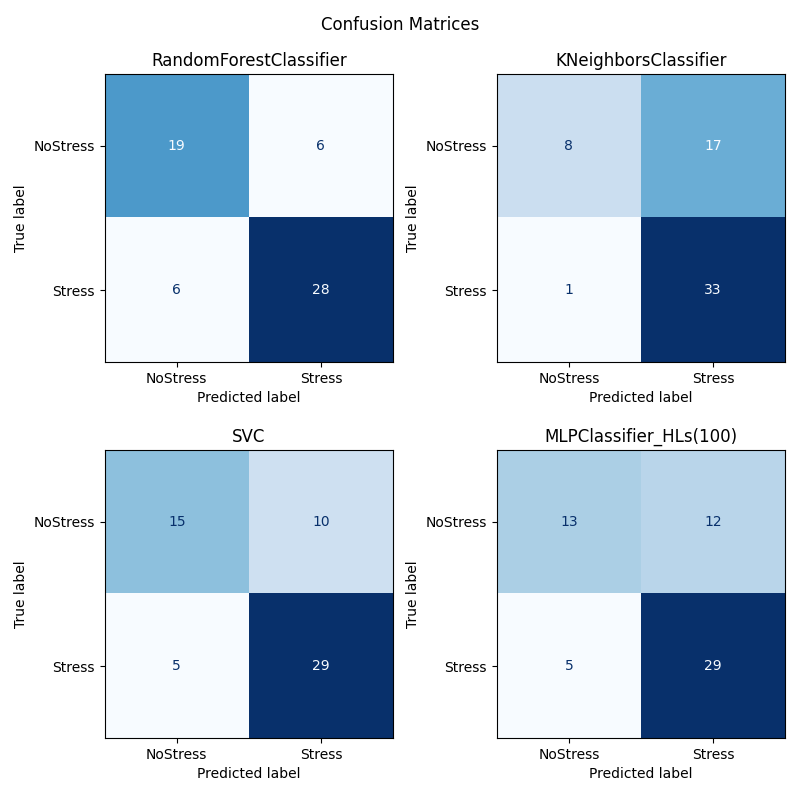

Model RandomForestClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192209_binary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192209_binary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192209_binary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192209_binary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.049829,0.049481,0.562055
MLPClassifier_HLs(100),0.033514,0.034265,0.759539
RandomForestClassifier,0.058874,0.061132,0.615932
SVC,0.050488,0.049642,0.740182


In [6]:
# 10 random splits holdout
if validations['holdout']:
    res, conf, models, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=False,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

    if not params["data_augmentation"]:
        for model_name, probs_df in probs_dict.items():
            agg_cols = {}
            for cls_idx, cls_name in enumerate(params["classes"]):
                agg_cols[cls_idx] = cls_name
            probs_df["Subject"] = [idx.split("_")[0] for idx in probs_df.index]
            probs_df["Task"] = [idx.split("_")[1] for idx in probs_df.index]
            probs_dict[model_name] = probs_df.rename(columns=agg_cols).reset_index(drop=True)

In [7]:
if not params["data_augmentation"]:
    for model_name, probs_df in probs_dict.items():
        print(f"\n{model_name}")
        plt.figure(figsize=(12, 6))

        tasks = sorted(probs_df['Task'].unique())
        x_positions = np.arange(len(tasks))
        width = 0.35

        # Plot bars and scatter points for each class
        for i, class_name in enumerate(params["classes"]):
            means = probs_df.groupby('Task')[class_name].mean()
            bars = plt.bar(x_positions + (i-0.5)*width, [means[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

            # Add scatter points
            for j, task in enumerate(tasks):
                task_data = probs_df[probs_df['Task'] == task][class_name]
                x_jitter = np.random.normal(0, 0.04, size=len(task_data))
                plt.scatter(np.repeat(x_positions[j] + (i-0.5)*width, len(task_data)) + x_jitter,
                        task_data, color='black', alpha=0.1, s=30)

        plt.xlabel('Task')
        plt.ylabel('Probability')
        plt.title(f'Class Probabilities by Task - {model_name}')
        plt.xticks(x_positions, tasks, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.05, 1.05)
        plt.tight_layout()
        plt.show()

        # Summary
        agg_cols = {}
        for cls_name in params["classes"]:
            agg_cols[cls_name] = ["mean", "count", "std"]
        probs_stats = probs_df.groupby("Task").agg(agg_cols)
        display(probs_stats)

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Saving results to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192413_VidsTasks_binary_10s&0.2_RFEf.21.csv, ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192413_VidsTasks_binary_10s&0.2_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.755330,0.752187,4.965716
MLPClassifier_HLs(100),0.783971,0.783499,5.019693
RandomForestClassifier,0.785555,0.785007,5.173435
SVC,0.823789,0.820415,5.219153


Saving confusion matrix to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192413_VidsTasks_binary_10s&0.2_RFEf.21.CM.png


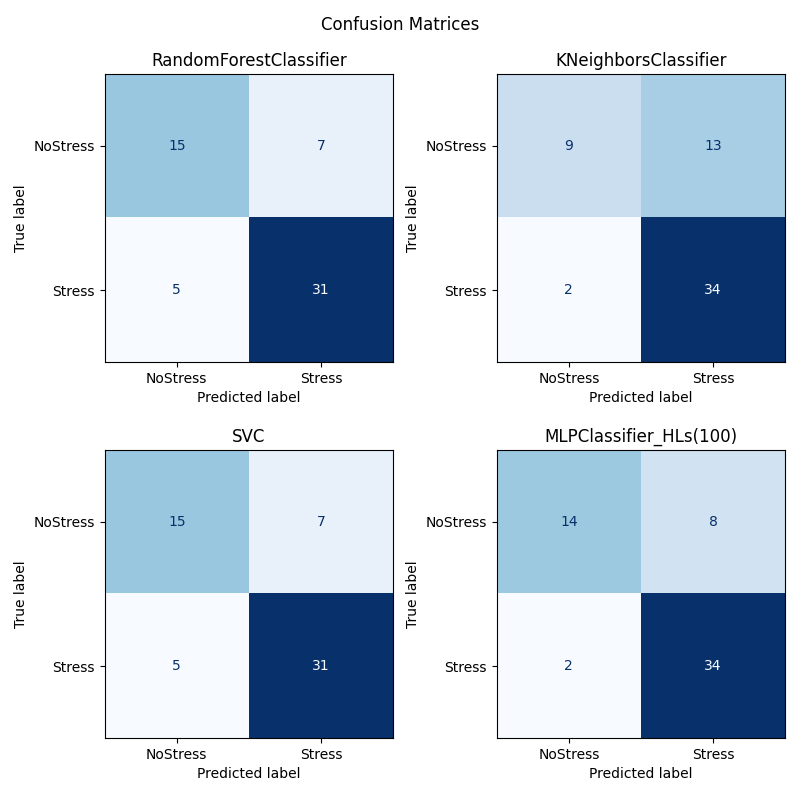

Model RandomForestClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192414_binary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192414_binary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192414_binary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192414_binary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 5-folds cross-validation:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.031835,0.048366,0.582217
MLPClassifier_HLs(100),0.063083,0.049304,0.805699
RandomForestClassifier,0.036952,0.036897,0.547084
SVC,0.044231,0.048881,0.554565


In [8]:
# 5-fold cross-validation
if validations['kfold']:
    res, conf, models, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=False,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

    if not params["data_augmentation"]:
        for model_name, probs_df in probs_dict.items():
            agg_cols = {}
            for cls_idx, cls_name in enumerate(params["classes"]):
                agg_cols[cls_idx] = cls_name
            probs_df["Subject"] = [idx.split("_")[0] for idx in probs_df.index]
            probs_df["Task"] = [idx.split("_")[1] for idx in probs_df.index]
            probs_dict[model_name] = probs_df.rename(columns=agg_cols).reset_index(drop=True)

In [9]:
if not params["data_augmentation"]:
    for model_name, probs_df in probs_dict.items():
        print(f"\n{model_name}")
        plt.figure(figsize=(12, 6))

        tasks = sorted(probs_df['Task'].unique())
        x_positions = np.arange(len(tasks))
        width = 0.35

        # Plot bars and scatter points for each class
        for i, class_name in enumerate(params["classes"]):
            means = probs_df.groupby('Task')[class_name].mean()
            bars = plt.bar(x_positions + (i-0.5)*width, [means[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

            # Add scatter points
            for j, task in enumerate(tasks):
                task_data = probs_df[probs_df['Task'] == task][class_name]
                x_jitter = np.random.normal(0, 0.04, size=len(task_data))
                plt.scatter(np.repeat(x_positions[j] + (i-0.5)*width, len(task_data)) + x_jitter,
                        task_data, color='black', alpha=0.1, s=30)

        plt.xlabel('Task')
        plt.ylabel('Probability')
        plt.title(f'Class Probabilities by Task - {model_name}')
        plt.xticks(x_positions, tasks, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.05, 1.05)
        plt.tight_layout()
        plt.show()

        # Summary
        agg_cols = {}
        for cls_name in params["classes"]:
            agg_cols[cls_name] = ["mean", "count", "std"]
        probs_stats = probs_df.groupby("Task").agg(agg_cols)
        display(probs_stats)

### Ternary classification

In [10]:
params['classification'] = 'ternary'
params['classes'] = TER_LABELS
show_label_stats(params['classes'], rel_ter_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy={0:150, 1:150, 2:150})
    x_in, y_in = ada.fit_resample(rel_X, rel_ter_y)
    print("Resampled dataset")
    show_label_stats(params['classes'], y_in)
else:
    x_in = rel_X.copy()
    y_in = rel_ter_y.copy()

,labels,counts,percentage
0,Relaxed,117,62.234043
1,Stress,36,19.148936
2,RealStress,35,18.617021


Resampled dataset


,labels,counts,percentage
0,Relaxed,154,36.320755
1,Stress,146,34.433962
2,RealStress,124,29.245283


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192832_VidsTasks_ternary_10s&0.2_RFEf.21.csv, ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192832_VidsTasks_ternary_10s&0.2_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.786353,0.787119,5.667673
MLPClassifier_HLs(100),0.804239,0.801474,5.757916
RandomForestClassifier,0.824857,0.819207,6.018141
SVC,0.867520,0.861382,5.636551


Saving confusion matrix to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192832_VidsTasks_ternary_10s&0.2_RFEf.21.CM.png


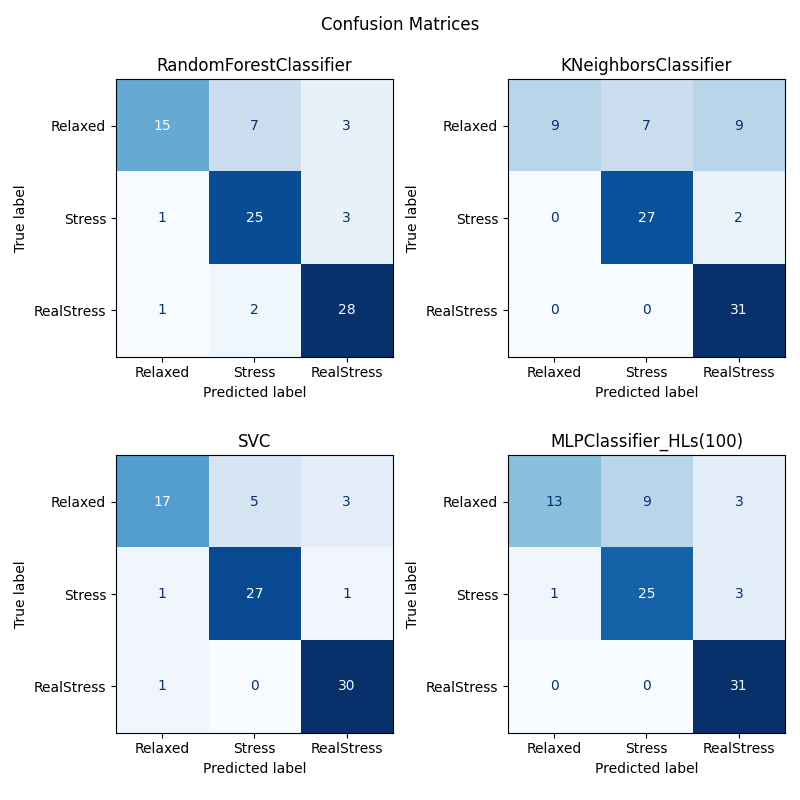

Model RandomForestClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192833_ternary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192833_ternary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192833_ternary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-192833_ternary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.046333,0.041264,0.531889
MLPClassifier_HLs(100),0.046009,0.042881,0.651441
RandomForestClassifier,0.040772,0.039705,0.560493
SVC,0.041988,0.042062,0.543166


In [11]:
# 10 random splits holdout
if validations["holdout"]:
    res, conf, models, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])


Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Saving results to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193046_VidsTasks_ternary_10s&0.2_RFEf.21.csv, ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193046_VidsTasks_ternary_10s&0.2_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.788293,0.789538,5.569826
MLPClassifier_HLs(100),0.839372,0.834022,5.226303
RandomForestClassifier,0.851424,0.845447,5.684239
SVC,0.858306,0.852783,5.371823


Saving confusion matrix to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193046_VidsTasks_ternary_10s&0.2_RFEf.21.CM.png


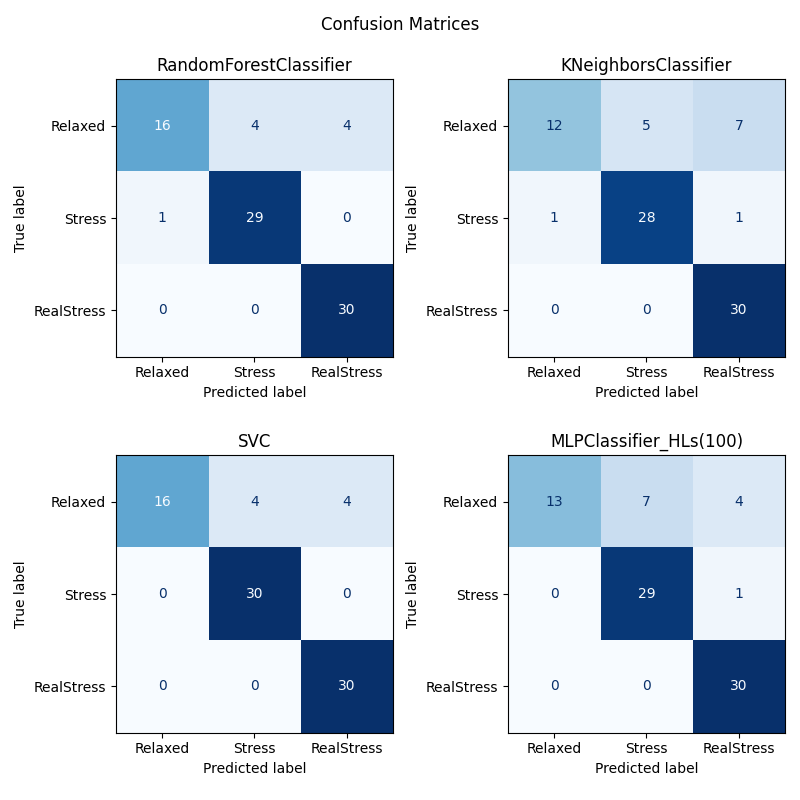

Model RandomForestClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193046_ternary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193047_ternary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193047_ternary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193047_ternary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 5-folds cross-validation:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.039907,0.035091,0.418718
MLPClassifier_HLs(100),0.020846,0.018749,0.269651
RandomForestClassifier,0.048469,0.048677,0.407319
SVC,0.039349,0.037514,0.537590


In [12]:
# 5-fold cross-validation
if validations["kfold"]:
    res, conf, models, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

### Quaternary Classification

In [13]:
params["classification"] = "quaternary"
params["classes"] = QAD_LABELS
show_label_stats(params["classes"], rel_qad_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy={0:95, 1:95, 2:95, 3:95})
    x_in, y_in = ada.fit_resample(rel_X, rel_qad_y)
    print("Resampled dataset")
    show_label_stats(params["classes"], y_in)
else:
    x_in = rel_X.copy()
    y_in = rel_qad_y.copy()

,labels,counts,percentage
0,Relaxed,73,38.829787
1,Stress,54,28.723404
2,RealStress,33,17.553191
3,Amused,28,14.893617


Resampled dataset


,labels,counts,percentage
0,Relaxed,105,27.486911
1,Stress,101,26.439791
2,RealStress,95,24.869110
3,Amused,81,21.204188


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193449_VidsTasks_quaternary_10s&0.2_RFEf.21.csv, ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193449_VidsTasks_quaternary_10s&0.2_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.781478,0.776782,5.400350
MLPClassifier_HLs(100),0.760354,0.759473,5.405654
RandomForestClassifier,0.730422,0.724546,5.589469
SVC,0.803915,0.797513,5.495685


Saving confusion matrix to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193449_VidsTasks_quaternary_10s&0.2_RFEf.21.CM.png


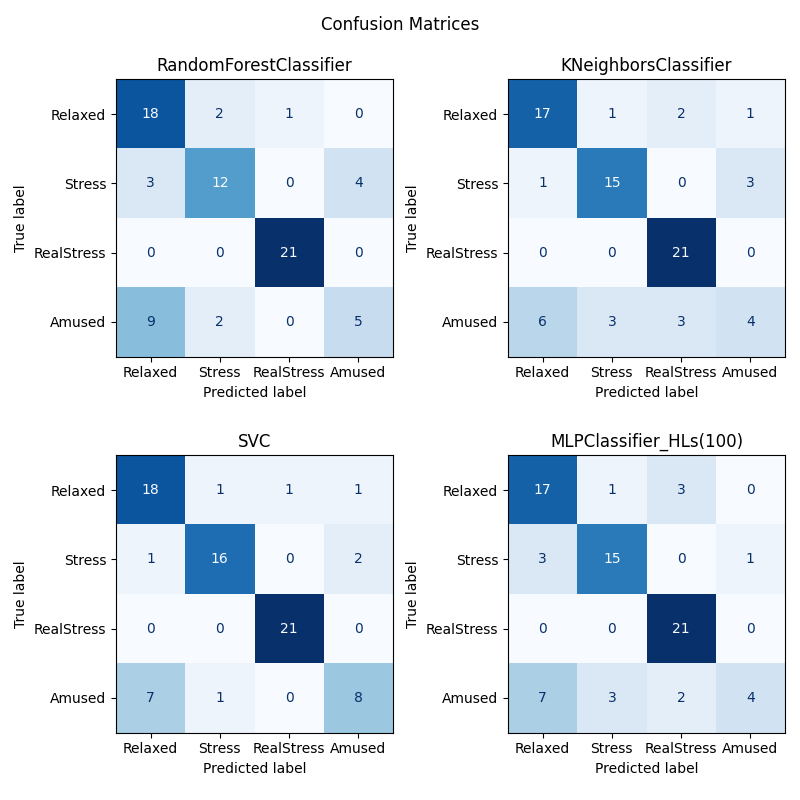

Model RandomForestClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193450_quaternary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193450_quaternary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193450_quaternary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193450_quaternary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.050410,0.048371,0.466500
MLPClassifier_HLs(100),0.038427,0.035120,0.457566
RandomForestClassifier,0.049100,0.049083,0.465980
SVC,0.022875,0.025916,0.576468


In [14]:
# 10 random splits holdout
if validations["holdout"]:
    res, conf, models, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Saving results to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193709_VidsTasks_quaternary_10s&0.2_RFEf.21.csv, ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193709_VidsTasks_quaternary_10s&0.2_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.788804,0.788417,5.449103
MLPClassifier_HLs(100),0.768549,0.766286,5.920721
RandomForestClassifier,0.730510,0.727158,5.729508
SVC,0.832186,0.827210,5.388731


Saving confusion matrix to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193709_VidsTasks_quaternary_10s&0.2_RFEf.21.CM.png


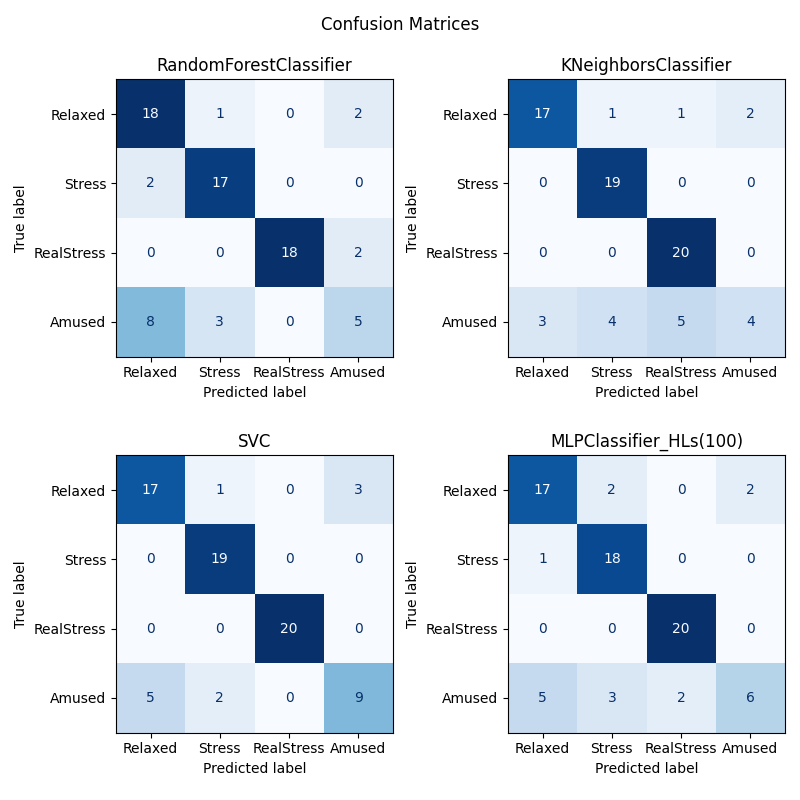

Model RandomForestClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193710_quaternary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193710_quaternary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193710_quaternary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../stressID/Classification/Results_StdSubject_VidTasks/20251016-193710_quaternary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 5-folds cross-validation:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.023384,0.019527,0.629678
MLPClassifier_HLs(100),0.040607,0.041433,0.693733
RandomForestClassifier,0.032632,0.027501,0.418641
SVC,0.073593,0.072455,0.506679


In [15]:
# 5-fold cross-validation
if validations["kfold"]:
    res, conf, models, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])